In [1]:
import numpy as np
import pandas as pd
import os
import json

In [2]:
df = pd.read_csv(r"C:\Users\nandi\Documents\ML_CO2_ER\data\df_merged.csv")
ea_data = pd.read_csv(r"C:\Users\nandi\Documents\ML_CO2_ER\data\Data_computed_properties\filtered_ip.csv")
ea_data.dropna(inplace=True)
ea_data.rename(columns={'solvent ID': 'solvent_ID', 'IP_0-1': 'IP_values'}, inplace=True)
df = df.merge(ea_data, on=['solvent_ID'], how="right")

In [3]:
df.head()

,solvent_ID,smiles_x,Binding_Energy_eV,solubility_CO2 [mol/L],viscosity [Pa s],nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,...,polarizability_ang3,min_partial_charge,max_partial_charge,min_abs_partial_charge,max_abs_partial_charge,vib_freq_min_cm1,vib_freq_max_cm1,vib_freq_count,smiles_y,IP_values
0,zinc_1345620175,C[C@H]([C@@H](N[C@@H]1CCCC[C@H]1F)C)O,-0.214742,0.079341,0.150835,0.0,1.0,15.711170,2.269900,4.539800,...,849.696107,-0.819411,0.453256,0.172385,0.819411,51.2361,3727.7322,93.0,C[C@H](N[C@@H]1CCCC[C@H]1F)[C@@H](C)O,0.724053
1,zinc_674912368,COC[C@@H](N1C[C@H]2[C@H](C1)CCC2)C,-0.214342,0.094735,0.011400,0.0,1.0,16.309342,2.417049,4.559183,...,924.031534,-0.779818,0.232699,0.000737,0.779818,35.7164,3128.8524,96.0,COC[C@H](C)N1C[C@@H]2CCC[C@H]2C1,0.255187
2,zinc_644654185,CC[C@H](CNCC(F)(F)C)O,-0.212998,0.096515,0.022542,0.0,1.0,11.751232,2.135779,4.271558,...,666.772267,-0.824957,0.633432,0.059057,0.824957,43.3486,3716.1399,72.0,CC[C@@H](O)CNCC(C)(F)F,1.070564
3,zinc_132906027,CC[C@H](C1CC1)NCCOCC(C)C,-0.215950,0.079947,0.004861,0.0,1.0,17.214239,2.324807,4.407461,...,1044.297027,-0.927964,0.380666,0.011509,0.927964,22.3711,3510.5041,111.0,CC[C@@H](NCCOCC(C)C)C1CC1,0.763281
4,zinc_156549661,C[C@@H](CN1CCC[C@H]1C)O,-0.198320,0.088578,0.081929,0.0,1.0,11.731206,2.268815,4.387099,...,709.790668,-0.610850,0.449006,0.051486,0.610850,43.4119,3722.5285,75.0,C[C@H](O)CN1CCC[C@H]1C,0.313528


In [4]:
df.rename(columns={'smiles_x': 'smiles'}, inplace=True)
df.drop("smiles_y", inplace=True, axis=1)

In [5]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2853 entries, 0 to 3100
Columns: 1421 entries, solvent_ID to IP_values
dtypes: float64(1419), object(2)
memory usage: 31.0+ MB


In [6]:
# df = df[(df["IP_values"] > -2) & (df["IP_values"] < 6)]

In [7]:
meta_cols = ['solvent_ID', 'smiles', 'solubility_CO2 [mol/L]', 'viscosity [Pa s]', 'Binding_Energy_eV']
target = 'IP_values'  # or 'solubility_CO2 [mol/L]', 'viscosity [Pa s]'
X = df.drop(columns=meta_cols + [target])
y = df[target]

<Axes: >

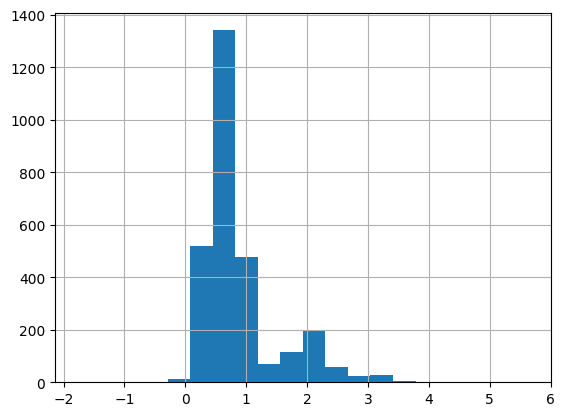

In [8]:
y.hist(bins=20)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# y_scaler = StandardScaler()
# y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
# y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

from sklearn.preprocessing import PowerTransformer

# Step 1: Initialize transformer
pt = PowerTransformer(method='yeo-johnson')

# Step 2: Fit and transform the target (y_train), transform y_test
# y_train_trans = pt.fit_transform(y_train.values.reshape(-1, 1)).flatten()
# y_test_trans = pt.transform(y_test.values.reshape(-1, 1)).flatten()

# 4. Model Training
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train_scaled, y_train_log)

<Axes: xlabel='IP_values', ylabel='Count'>

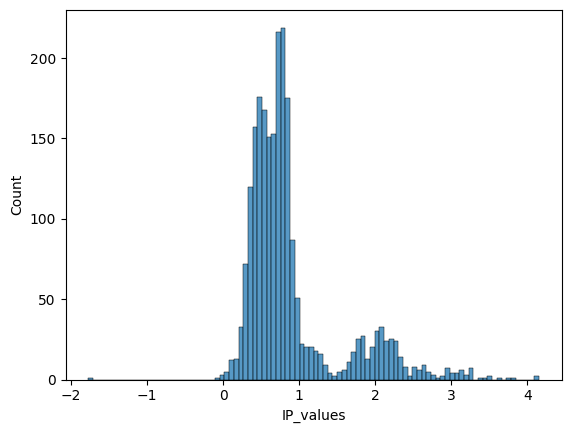

In [12]:
import seaborn as sns
sns.histplot(y_train)

In [13]:
# !pip install xgboost

In [14]:
from sklearn.model_selection import RandomizedSearchCV
# # XGB model with GPU support
from xgboost import XGBRegressor
xgb = XGBRegressor(
    tree_method='hist',  # key line for GPU
    device='cuda', 
    random_state=42
)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_lambda': [0.1, 0.5, 1, 5]
}


# # RandomizedSearchCV with GPU-based XGBoost
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=10,
    verbose=1,
    n_jobs=1  # must be 1 when using GPU with XGBoost
)

# # Train the model
random_search.fit(X_train_scaled, y_train)

# Evaluate best model
# best_model = random_search.best_estimator_

# model = XGBRegressor(
#     tree_method='gpu_hist',
#     device='cuda',
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_lambda=10,
#     learning_rate=0.01,
#     n_estimators=500,
#     max_depth=6,
#     random_state=42
# )

# model.fit(X_train_scaled, y_train_log)

Fitting 10 folds for each of 30 candidates, totalling 300 fits


c:\Users\nandi\Documents\ML_CO2_ER\venv\Lib\site-packages\xgboost\core.py:774: UserWarning: [19:57:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies 

In [15]:
best_params = random_search.best_params_
final_model = XGBRegressor(
    **best_params,
    tree_method='hist',
    device='cuda',
    random_state=42
)

In [16]:
final_model.fit(
    X_train_scaled,
    y_train,
    verbose=True
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

In [17]:
final_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

In [18]:
final_model.get_params

<bound method XGBModel.get_params of XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)>

In [38]:

# 5. Evaluation
# y_pred_log = model.predict(X_test_scaled)
# ------------------- Step 5: Predict and Inverse Transform ------------------- #
y_pred_orig = final_model.predict(X_test_scaled)
y_pred_train = final_model.predict(X_train_scaled)
# y_pred_trans = final_model.predict(X_test_scaled)

# Inverse transform predictions back to original scale
# y_pred_orig = pt.inverse_transform(y_pred_trans.reshape(-1, 1)).flatten()
# y_pred_orig = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
# Inverse log1p
# y_pred = np.expm1(y_pred_log)
# y_test = np.expm1(y_test)

from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred_orig))
r2 = r2_score(y_test, y_pred_orig)
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.1916
R² Score: 0.9095


In [39]:
feature_names = X.columns.tolist()  # This should match the model's input

In [40]:
# !pip install --force-reinstall --no-deps numpy==1.26.4
# !pip install --upgrade shapely

In [41]:
# import shap
# import xgboost as xgb
# booster = final_model.get_booster()

# # 2. Save it to a temporary JSON file
# # This forces XGBoost to write the metadata in a standard format
# model_bytearray = booster.save_raw(raw_format="json")

# # 3. Load it back into a "clean" booster object
# # This strips the weird Scikit-Learn wrapper formatting causing the crash
# clean_model = xgb.Booster()
# clean_model.load_model(model_bytearray)

# # 4. Use the Clean Model with SHAP
# explainer = shap.TreeExplainer(clean_model)
# shap_values = explainer(X_test_scaled)

# # 5. Fix Feature Names (Critical Step)
# # The raw booster lost the column names, so we put them back for the plot
# shap_values.feature_names = list(X.columns)

# # 6. Plot
# shap.plots.bar(shap_values, max_display=10)
# shap.plots.beeswarm(shap_values, max_display=10)

In [42]:
len(X_test_scaled)
len(X_train_scaled)
len(X.columns)

1415

In [43]:
1415*2

2830

In [44]:
# ...existing code...
import shap
import numpy as np
import pandas as pd

# build DataFrame so SHAP keeps feature names and ensure numeric values
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
X_test_df = X_test_df.apply(pd.to_numeric, errors="coerce").fillna(X_test_df.mean().fillna(0))

# make model callable for SHAP
predict_fn = lambda data: final_model.predict(np.asarray(data))

# create masker (Independent preferred; fallback to Data)
try:
    masker = shap.maskers.Independent(X_test_df)
except Exception:
    masker = shap.maskers.Data(X_test_df)

# create explainer with callable and masker, then explain
# create explainer with callable and masker, then explain
explainer = shap.Explainer(predict_fn, masker, feature_names=feature_names)

# permutation explainer requires at least 2*num_features + 1 evaluations
min_evals = 2 * X_test_df.shape[1] + 1
# choose a target (>= min_evals). adjust 3000 as desired for accuracy/performance
max_evals = max(3000, min_evals)
print(f"Running SHAP permutation explainer with max_evals={max_evals} (min required {min_evals})")

shap_values = explainer(X_test_df, max_evals=max_evals)

# plot top features (or compute top-10 as you prefer)

Running SHAP permutation explainer with max_evals=3000 (min required 2831)


PermutationExplainer explainer: 572it [55:57,  5.89s/it]                           


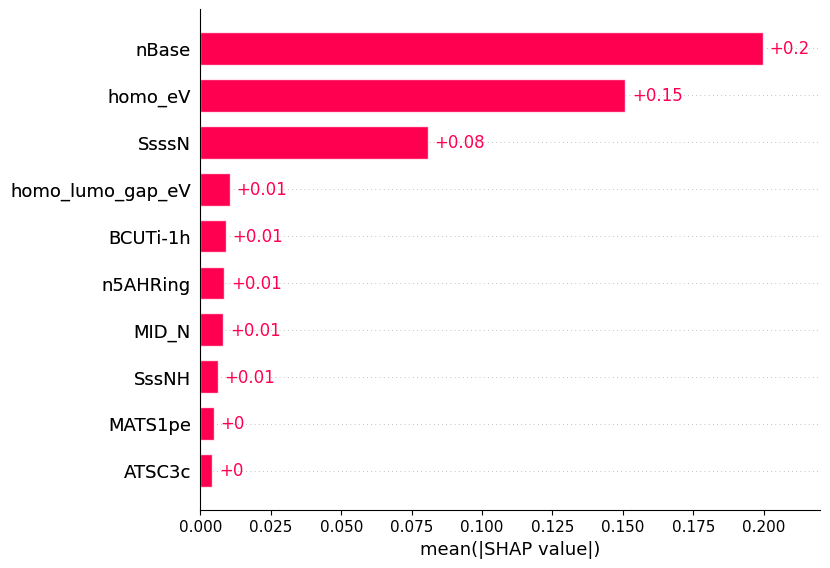

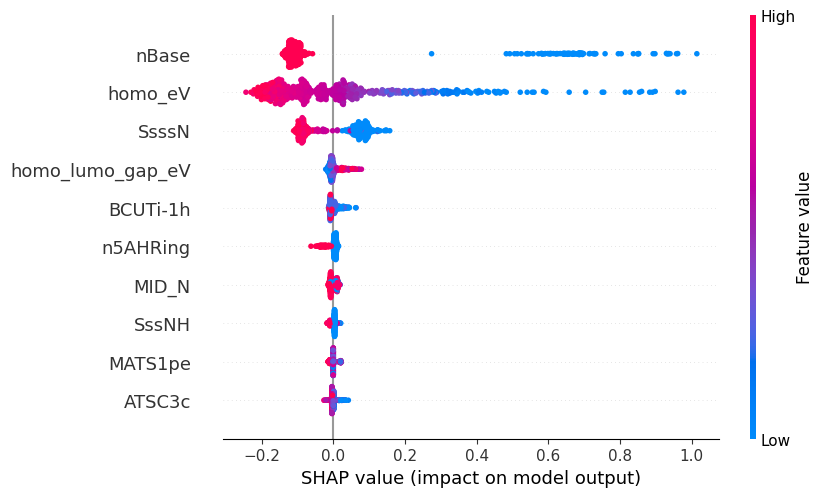

In [49]:
mean_shap = np.abs(shap_values.values).mean(axis=0)
top_10_indices = np.argsort(mean_shap)[-10:][::-1]

# Slice SHAP explanation to include only top 10 features
shap_values_top10 = shap.Explanation(
    values=shap_values.values[:, top_10_indices],
    base_values=shap_values.base_values,
    data=shap_values.data[:, top_10_indices],
    feature_names=np.array(shap_values.feature_names)[top_10_indices].tolist()
)

# Plot only top 10 features
shap.plots.bar(shap_values_top10)
shap.plots.beeswarm(shap_values_top10)

In [50]:
# import shap
# print(shap.__version__)

# explainer = shap.Explainer(final_model, X_test_scaled, feature_names=X.columns)
# shap_values = explainer(X_test_scaled)

# shap.plots.bar(shap_values, max_display=10)
# shap.plots.beeswarm(shap_values, max_display=10)

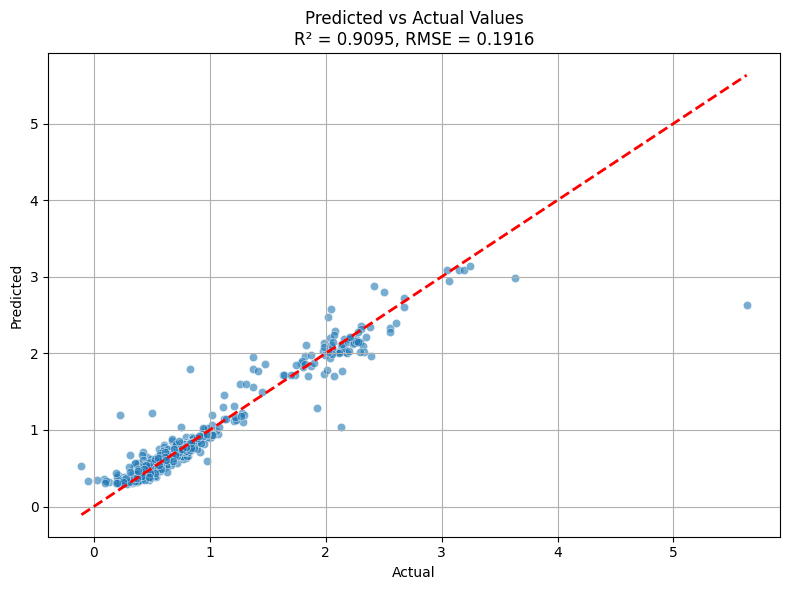

In [51]:
residuals = y_test - y_pred_orig

import matplotlib.pyplot as plt
import seaborn as sns 

# --- A. Predicted vs Actual Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_orig, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.title(f"Predicted vs Actual Values\nR² = {r2:.4f}, RMSE = {rmse:.4f}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

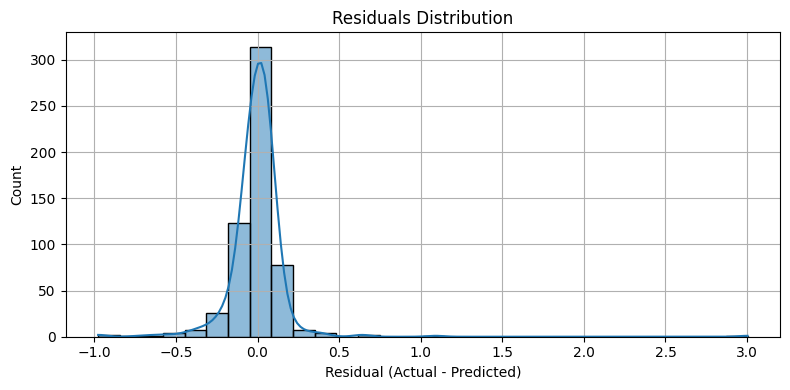

In [52]:
# --- B. Histogram of Residuals ---
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [53]:
import pandas as pd
import numpy as np

# 1. Get feature importance from SHAP
# Sum the absolute SHAP values for each feature to find the top ones
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='importance', ascending=False)

# 2. Select the top 6 features (adjust this number if you want a more precise equation)
top_features = feature_importance['feature'].head(10).tolist()

print(f"Top features for equation: {top_features}")

Top features for equation: ['nBase', 'homo_eV', 'SsssN', 'homo_lumo_gap_eV', 'BCUTi-1h', 'n5AHRing', 'MID_N', 'SssNH', 'MATS1pe', 'ATSC3c']


In [54]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Convert the scaled arrays back to DataFrames so we can use column names
# We use the original column names from 'X'
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# 2. Now we can subset using the names you found
X_train_simple = X_train_df[top_features]
X_test_simple = X_test_df[top_features]

# 3. Fit the Simple Linear Model
linear_model = LinearRegression()
linear_model.fit(X_train_simple, y_train)

# 4. Check accuracy
y_pred_linear = linear_model.predict(X_test_simple)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_lin = r2_score(y_test, y_pred_linear)

print("--- Simple Linear Equation ---")
print(f"RMSE: {rmse_lin:.4f}")
print(f"R² Score: {r2_lin:.4f}")
print("\nPredictive Equation:")
equation_terms = [f"({coef:.4f} * {name})" for name, coef in zip(top_features, linear_model.coef_)]
print(f"y = {linear_model.intercept_:.4f} + " + " + ".join(equation_terms))

--- Simple Linear Equation ---
RMSE: 0.1836
R² Score: 0.9168

Predictive Equation:
y = 0.8920 + (-0.1887 * nBase) + (-0.4772 * homo_eV) + (-0.1816 * SsssN) + (-0.0665 * homo_lumo_gap_eV) + (-0.0590 * BCUTi-1h) + (-0.0095 * n5AHRing) + (0.0880 * MID_N) + (-0.1085 * SssNH) + (0.0701 * MATS1pe) + (-0.0184 * ATSC3c)


In [55]:
comp = list(zip(y_test[:10], y_pred_orig[:10], y_pred_linear[:10]))

In [56]:
print("Y_test, Y_pred_XGB, Y_pred_linear:")
comp

Y_test, Y_pred_XGB, Y_pred_linear:


[(0.6227301533659997, np.float32(0.5479516), np.float64(0.4369683680542731)),
 (0.9099635233172024, np.float32(0.8952375), np.float64(0.9054255123787731)),
 (0.4800240746113298, np.float32(0.51996315), np.float64(0.5686435330501977)),
 (0.8320091378243779, np.float32(0.8117429), np.float64(0.911849330937546)),
 (0.987369915024514, np.float32(0.9210002), np.float64(1.422653335401653)),
 (0.5008277388606599, np.float32(0.4538154), np.float64(0.28313058301769334)),
 (0.2494936601064417, np.float32(0.31958318), np.float64(0.3022399456390372)),
 (0.584867956475783, np.float32(0.49919277), np.float64(0.6039742397218699)),
 (0.9163261678771536, np.float32(0.7085638), np.float64(1.0398045032699104)),
 (1.807168209325881, np.float32(1.8248687), np.float64(2.188006947910667))]

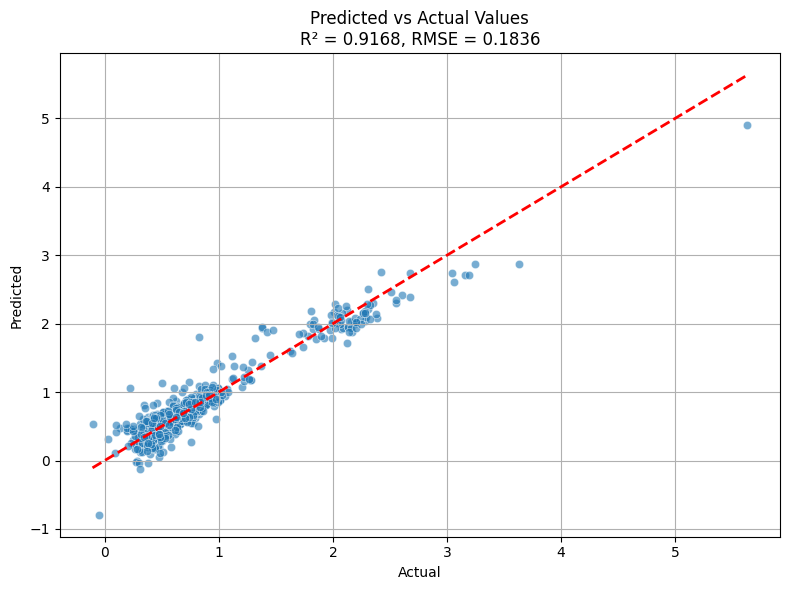

In [57]:
residuals_lin = y_test - y_pred_linear

import matplotlib.pyplot as plt
import seaborn as sns 

# --- A. Predicted vs Actual Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.title(f"Predicted vs Actual Values\nR² = {r2_lin:.4f}, RMSE = {rmse_lin:.4f}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\nandi\AppData\Local\Temp\ipykernel_17024\3958677613.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


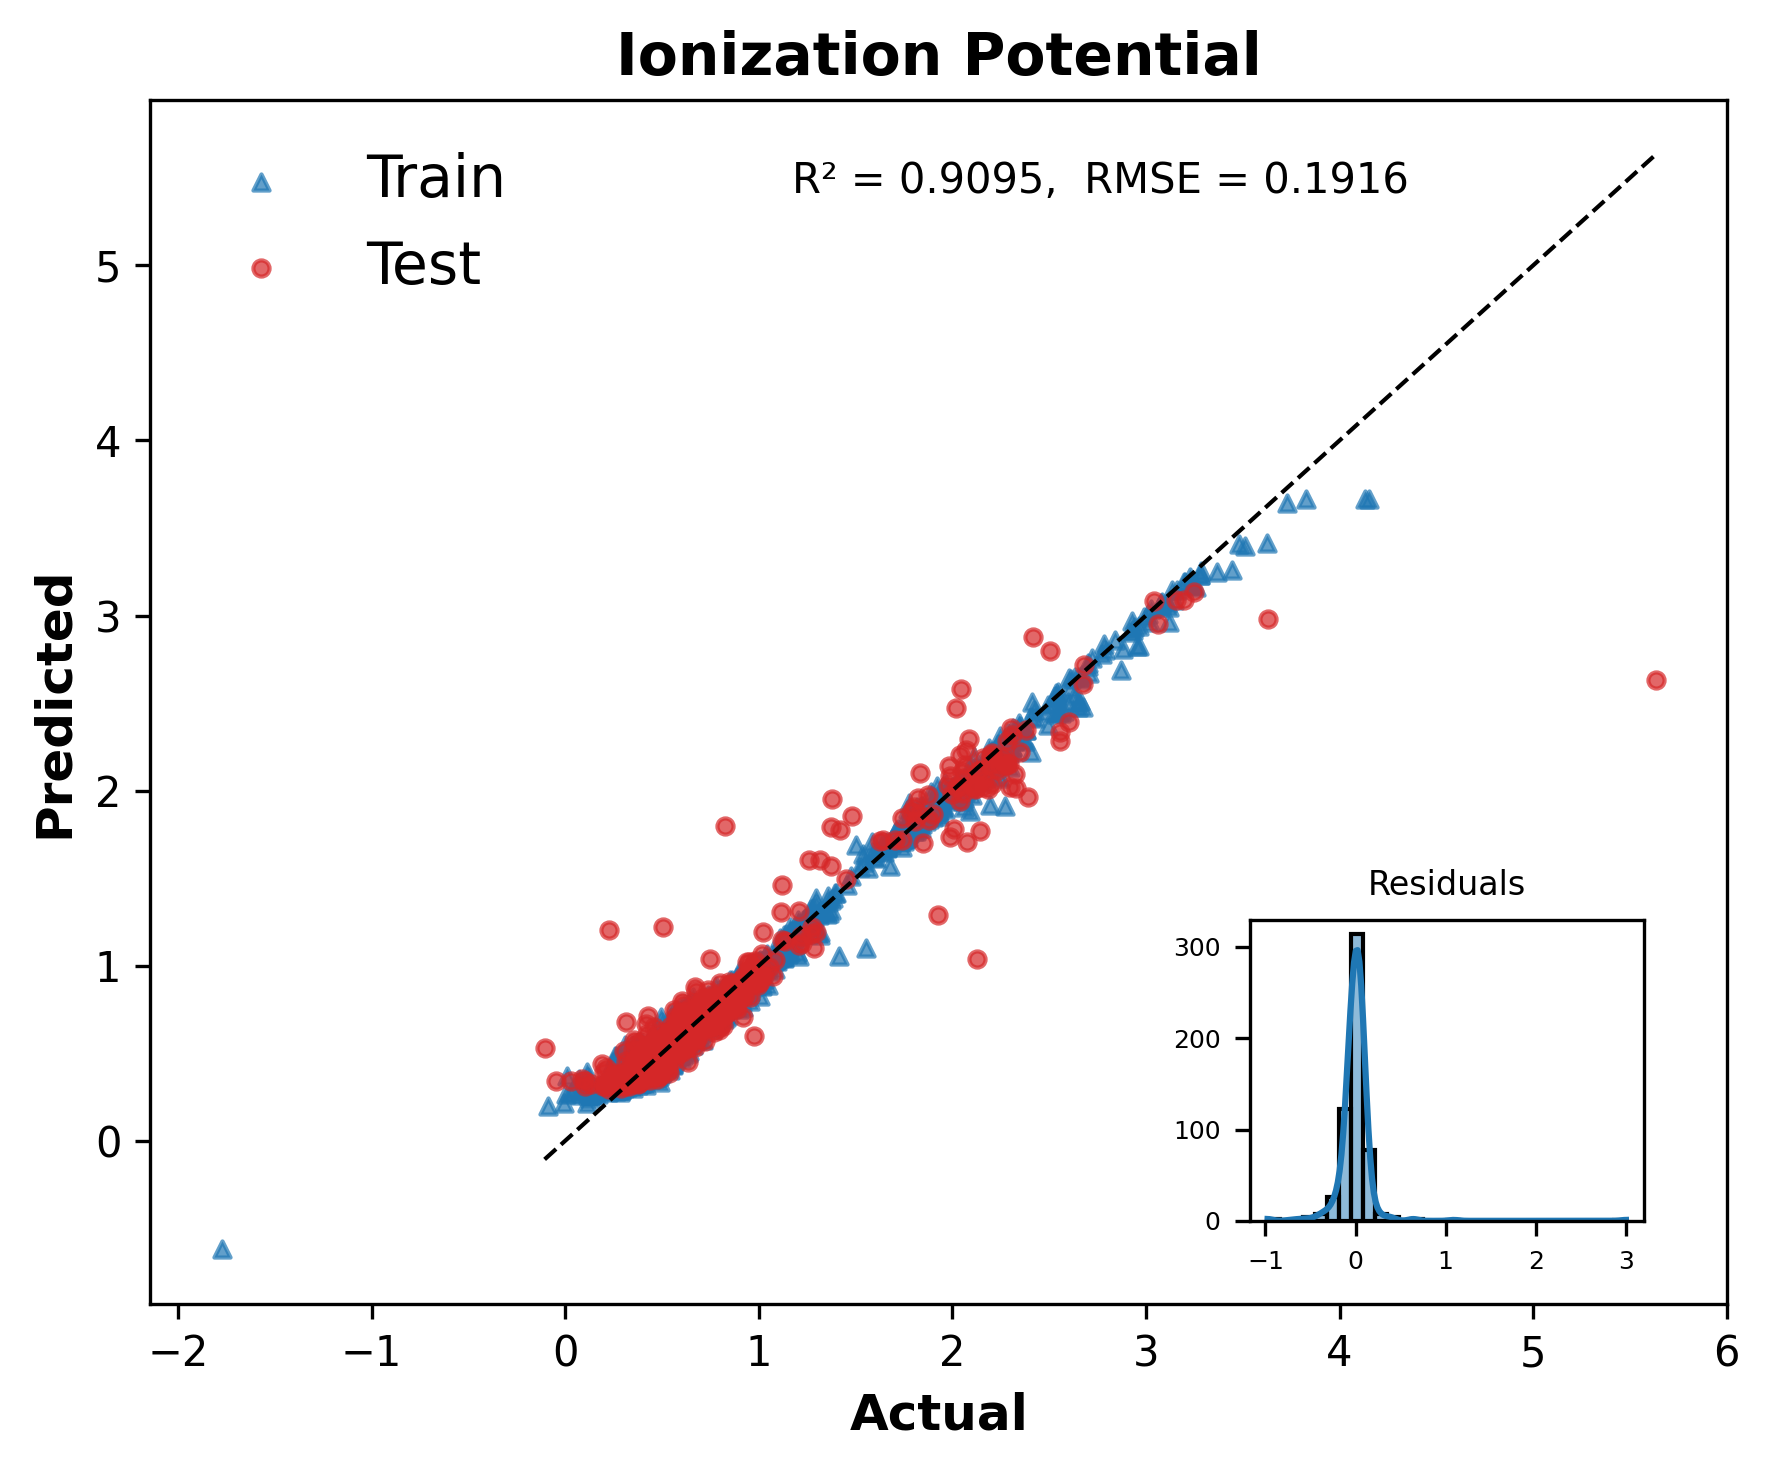

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ➤ Create main plot with better layout engine
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# ➤ Scatter: Train and Test
ax.scatter(y_train, y_pred_train, alpha=0.7, s=15, color='tab:blue', marker='^', label='Train')
ax.scatter(y_test, y_pred_orig, alpha=0.7, s=15, color='tab:red', marker='o', label='Test')

# ➤ Diagonal reference line
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1)

# ➤ Title and axes labels
ax.set_title("Ionization Potential", fontsize=14, fontweight='bold')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)

# ➤ Custom legend with performance metrics
# ax.legend(title=f"RMSE = {rmse:.4f}\nR² = {r2:.4f}", loc='upper left', fontsize=10, title_fontsize=10, frameon=False)

x_center = (y_test.min() + y_test.max()) / 2
# y_top = y_pred_orig.max() + (y_pred_orig.max() - y_pred_orig.min()) * 0.15
y_top = ax.get_ylim()[1] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
ax.text(x_center, y_top, f"R² = {r2:.4f},  RMSE = {rmse:.4f}",
        fontsize=10, ha='center', va='top')

# ➤ Legend
ax.legend(loc='upper left', fontsize=14, frameon=False)
# ➤ Inset residual plot
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)

# ➤ Save and display
plt.tight_layout()
plt.savefig("predicted_vs_actual_with_train_test.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\nandi\AppData\Local\Temp\ipykernel_17024\4189611168.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11, loc='upper left')


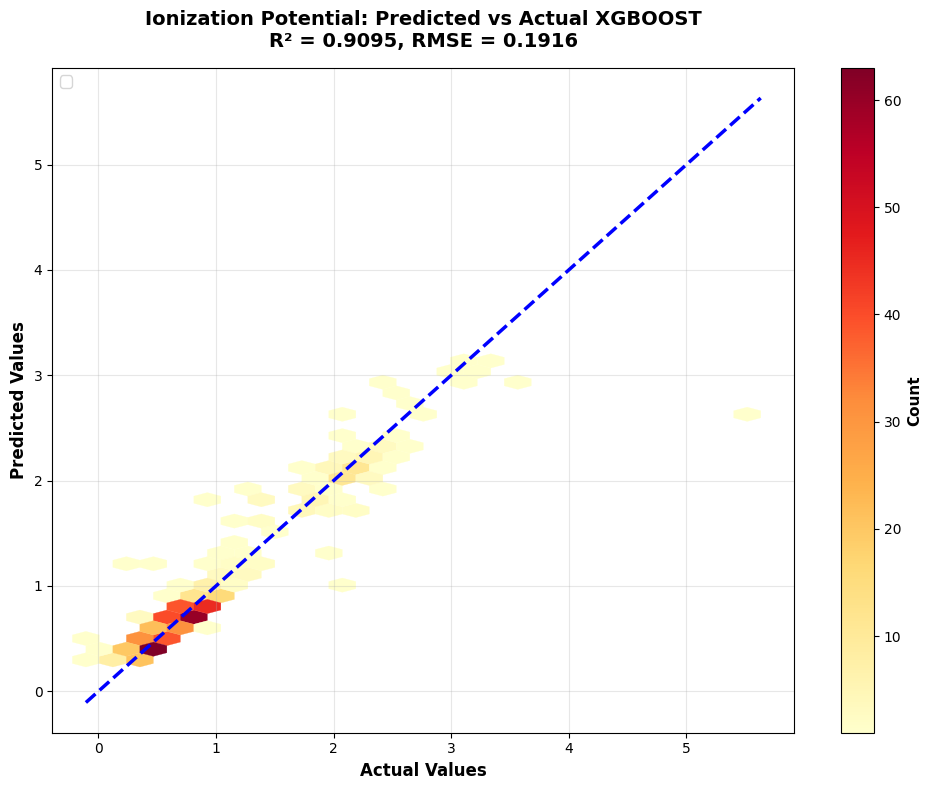

In [64]:
# Use point density plot (e.g. hexbin in matplotlib) instead of scatter plot for above to show the distribution information for the overlapped data points along with labeling the axes and adding a diagonal reference line.
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

# Create hexbin plot with better visibility
hb = ax.hexbin(y_test, y_pred_orig, gridsize=25, cmap='YlOrRd', mincnt=1, edgecolors='face', linewidths=0.2)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')

# Diagonal reference line
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', linewidth=2.5)

# Title and axes labels
ax.set_title(f"Ionization Potential: Predicted vs Actual XGBOOST\nR² = {r2:.4f}, RMSE = {rmse:.4f}", 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Actual Values", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted Values", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hexbin_density_plot.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\nandi\AppData\Local\Temp\ipykernel_17024\2866260507.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11, loc='upper left')


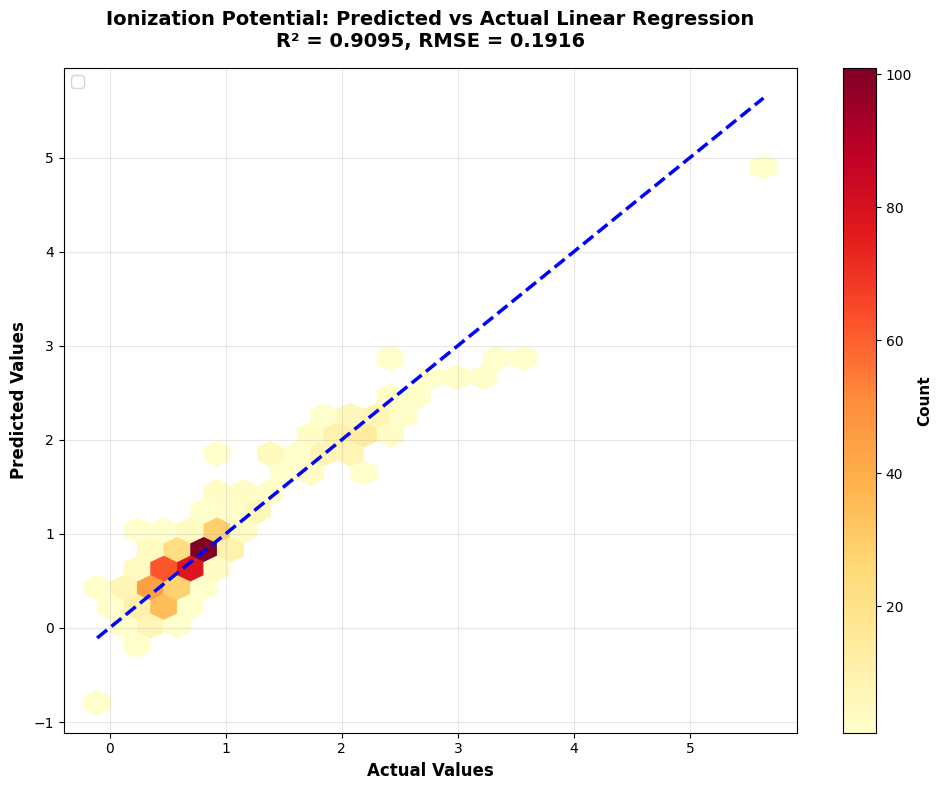

In [ ]:
# Use point density plot (e.g. hexbin in matplotlib) instead of scatter plot for above to show the distribution information for the overlapped data points along with labeling the axes and adding a diagonal reference line.
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

# Create hexbin plot with better visibility
hb = ax.hexbin(y_test, y_pred_linear, gridsize=25, cmap='YlOrRd', mincnt=1, edgecolors='face', linewidths=0.2)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')

# Diagonal reference line
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', linewidth=2.5)

# Title and axes labels
ax.set_title(f"Ionization Potential: Predicted vs Actual Linear Regression\nR² = {r2:.4f}, RMSE = {rmse:.4f}", 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Actual Values", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted Values", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hexbin_density_plot.png", dpi=300, bbox_inches='tight')
plt.show()